In [1]:
import os

import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re

import matplotlib.pyplot as plt

In [2]:
PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

In [3]:
df = pd.read_csv(PATH_OUT + '\\rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


In [4]:
df.dropna(subset=["Distance"], inplace=True)
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

In [5]:
def normalize_street_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip().lower()  #всё сразу в нижний регистр

    # Удаляем существующие префиксы
    if name.startswith(('ул.', 'ул ')):
        parts = name.split(maxsplit=1)
        name = parts[1] if len(parts) > 1 else ''

    name = name.replace('.', '').strip()

    if not name:
        return np.nan

    return f'ул. {name}'  

df['Start Location'] = df['Start Location'].apply(normalize_street_name)
df['End Location'] = df['End Location'].apply(normalize_street_name)

df['Start District'] = df['Start District'].apply(lambda x: x.lower() if isinstance(x, str) else x)
df['End District'] = df['End District'].apply(lambda x: x.lower() if isinstance(x, str) else x)

df['Start District'] = df['Start District'].str.replace('северо западный', 'северо-западный')
df['End District'] = df['End District'].str.replace('северо западный', 'северо-западный')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0


In [27]:
missing_districts = df[df['Start Location'].isna()] 
print(f"Пропусков в Start District: {len(missing_districts)}")
print(missing_districts[['Start Location', 'End Location', 'Start District']].head(10))

Пропусков в Start District: 7802
    Start Location End Location   Start District
18             NaN          NaN        ленинский
51             NaN          NaN      центральный
52             NaN          NaN    юго-восточный
79             NaN          NaN    юго-восточный
86             NaN          NaN    юго-восточный
92             NaN          NaN    юго-восточный
139            NaN          NaN      октябрьский
163            NaN          NaN    юго-восточный
167            NaN          NaN        ленинский
175            NaN          NaN  северо-западный


In [7]:
df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time Start,Time End,Duration,Speed (km/h),Time of Day,Start Hour,Day of Week
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266,Утро,9,Saturday
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138,Утро,9,Saturday
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860,Утро,9,Saturday
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806,Утро,9,Saturday
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826,Утро,9,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131,Ночь,23,Monday
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008,Ночь,23,Monday
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937,Ночь,23,Monday
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211,Ночь,23,Monday


In [8]:
df = df[df['Speed (km/h)'] <= 50]
df = df[df['Distance'] <= 10000]
df.dropna(subset=['Distance'], inplace=True)
df = df[(df['Duration'] > 1) & (df['Duration'] < 120)]
print("Пропущенные значения в колонке Distance:", df['Distance'].isna().sum())

Пропущенные значения в колонке Distance: 0


In [9]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time Start,Time End,Duration,Speed (km/h),Time of Day,Start Hour,Day of Week
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,4,Весна,Весна,09:01:03,09:24:45,23.700000,10.301266,Утро,9,Saturday
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,09:01:07,09:29:32,28.416667,9.533138,Утро,9,Saturday
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,4,Весна,Весна,09:04:27,09:42:46,38.316667,7.077860,Утро,9,Saturday
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,09:06:34,09:38:23,31.816667,7.318806,Утро,9,Saturday
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,09:09:27,09:40:07,30.666667,7.882826,Утро,9,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,23:45:06,00:06:55,21.816667,9.081131,Ночь,23,Monday
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,8,Лето,Лето,23:46:01,00:25:35,39.566667,7.570008,Ночь,23,Monday
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,8,Лето,Лето,23:48:04,00:09:21,21.283333,7.839937,Ночь,23,Monday
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,23:51:41,00:38:04,46.383333,8.364211,Ночь,23,Monday


Start Season
Весна    26.396289
Лето     26.367433
Name: Duration, dtype: float64
Day of Week
Sunday       17697
Saturday     17534
Friday       13759
Monday       12396
Wednesday    11370
Thursday     11233
Tuesday      10897
Name: count, dtype: int64
Start Hour
0     1132
1      552
2      426
3      186
4      210
5      812
6     2396
7     3429
8     3856
9     3729
10    3606
11    3170
12    3537
13    4073
14    5142
15    5938
16    6919
17    7583
18    8017
19    8490
20    7945
21    6182
22    4715
23    2841
Name: count, dtype: int64


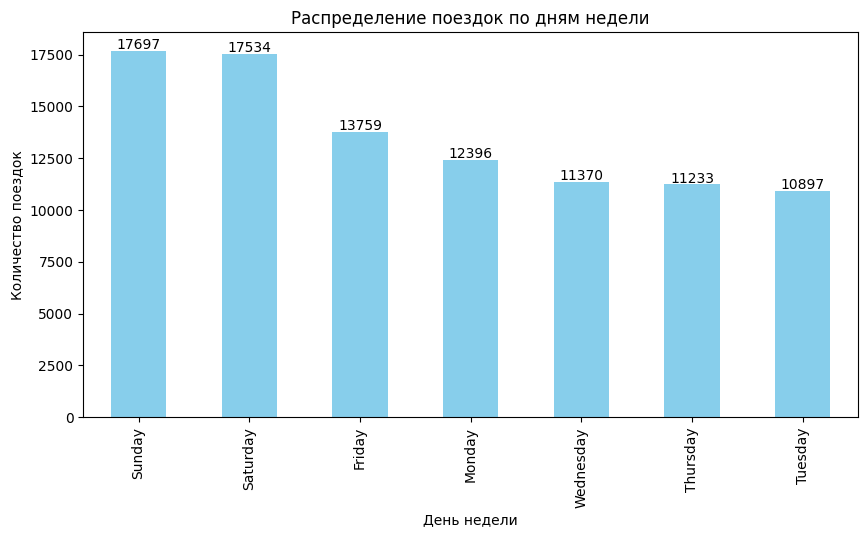

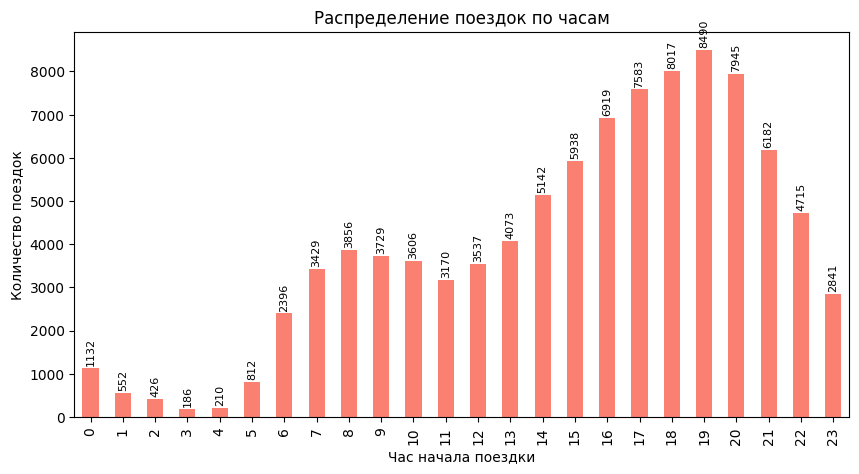

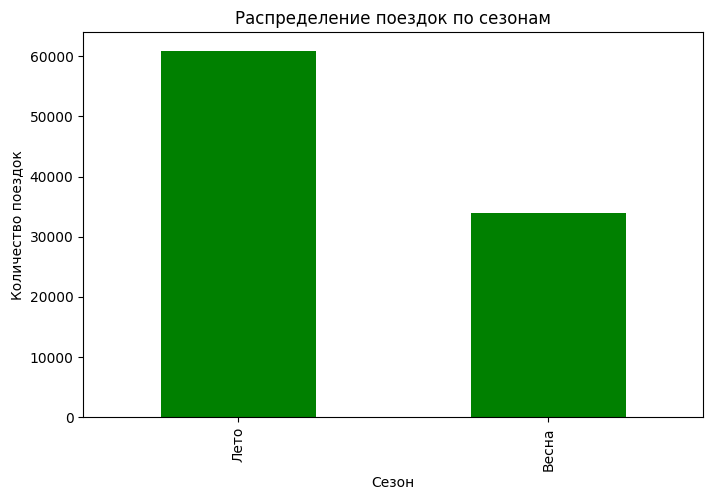

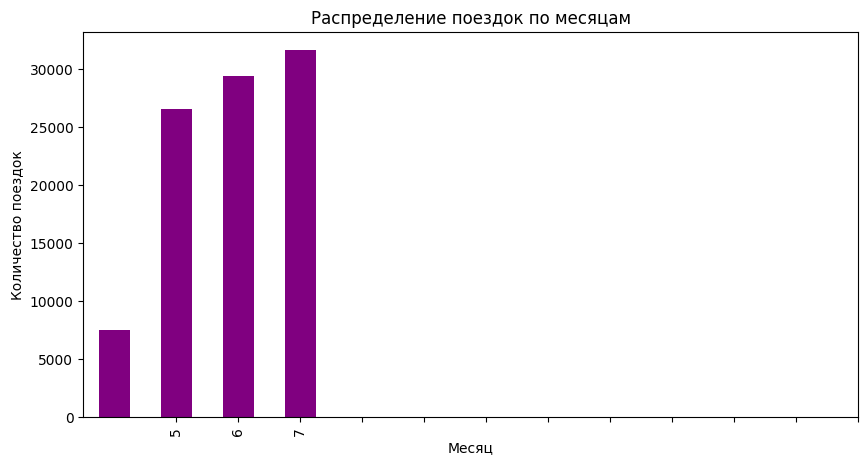

In [10]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()

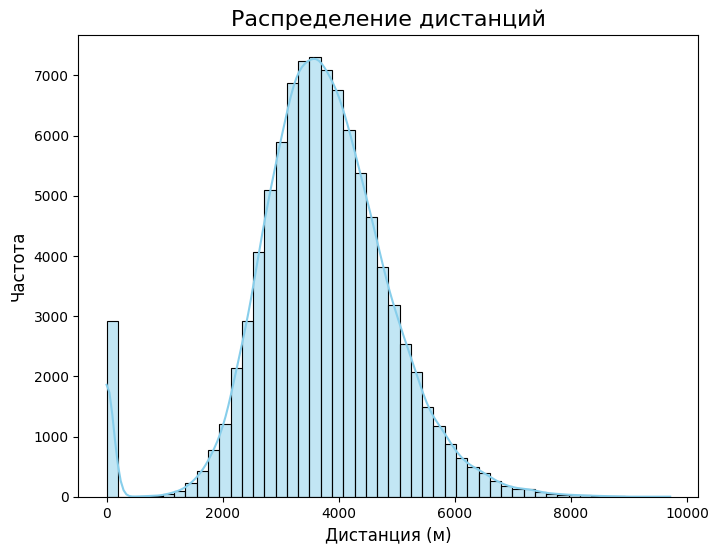

In [11]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

In [12]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


df['Weekday'] = df['Start Date'].dt.weekday
df['Start Hour'] = df['Start Date'].dt.hour

df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

df['Trip Cost'] = df['Duration'] * df['Rate per Minute']
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Time Start,Time End,Duration,Speed (km/h),Time of Day,Start Hour,Day of Week,Weekday,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,ул. шевченко,юго-восточный,ул. майская,октябрьский,4069.0,0,4,...,09:01:03,09:24:45,23.700000,10.301266,Утро,9,Saturday,5,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,ул. чехова,заречный,ул. спортивная,октябрьский,4515.0,0,4,...,09:01:07,09:29:32,28.416667,9.533138,Утро,9,Saturday,5,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,ул. буденного,октябрьский,ул. суворова,ленинский,4520.0,0,4,...,09:04:27,09:42:46,38.316667,7.077860,Утро,9,Saturday,5,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,ул. труда,центральный,ул. рабочая,северо-западный,3881.0,0,4,...,09:06:34,09:38:23,31.816667,7.318806,Утро,9,Saturday,5,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,ул. первомайская,северо-западный,ул. юбилейная,юго-восточный,4029.0,0,4,...,09:09:27,09:40:07,30.666667,7.882826,Утро,9,Saturday,5,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,ул. озерная,юго-восточный,ул. первомайская,северо-западный,3302.0,0,7,...,23:45:06,00:06:55,21.816667,9.081131,Ночь,23,Monday,0,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,ул. мичурина,ленинский,ул. садовая,заречный,4992.0,0,7,...,23:46:01,00:25:35,39.566667,7.570008,Ночь,23,Monday,0,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,ул. лермонтова,ленинский,ул. куйбышева,центральный,2781.0,0,7,...,23:48:04,00:09:21,21.283333,7.839937,Ночь,23,Monday,0,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,ул. рябиновая,северо-западный,ул. энергетиков,юго-восточный,6466.0,0,7,...,23:51:41,00:38:04,46.383333,8.364211,Ночь,23,Monday,0,5,231.916667


C:\Temp\ipykernel_16988\3707444050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time of Day', data=df, palette='Set2')


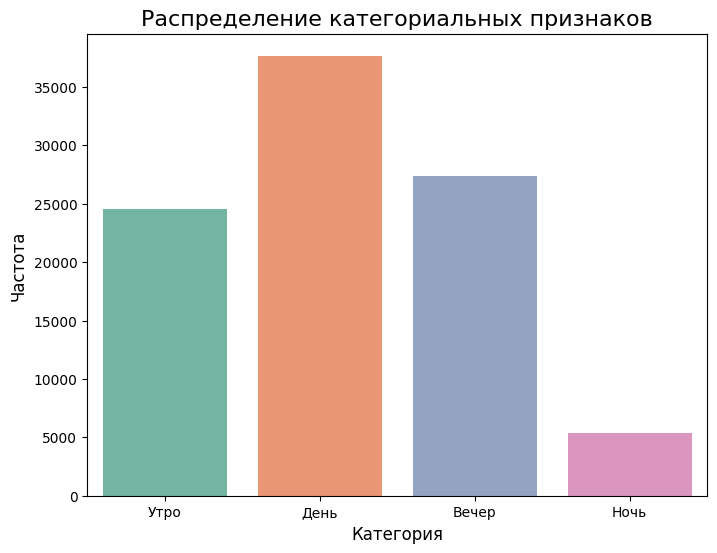

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [14]:
# Группируем по району и признаку промо
promo = df.groupby(['Start District', 'Promo']).size().unstack(fill_value=0)
promo.columns = ['Без промо', 'С промо']
promo['Всего поездок'] = promo['Без промо'] + promo['С промо']

# Доля промо-поездок
promo['Доля промо'] = promo['С промо'] / promo['Всего поездок']
promo = promo.sort_values(by='Доля промо', ascending=False)

promo

,Без промо,С промо,Всего поездок,Доля промо
Start District,,,,
заречный,8899,208,9107,0.022840
северо-западный,14788,326,15114,0.021569
ленинский,14852,324,15176,0.021349
юго-восточный,17646,376,18022,0.020863
октябрьский,12804,266,13070,0.020352
центральный,24035,362,24397,0.014838


In [15]:
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               16024
1   Будний день    юго-восточный               11252
2   Будний день        ленинский                9413
3   Будний день  северо-западный                9375
4   Будний день      октябрьский                8023
5   Будний день         заречный                5568
6      Выходной      центральный                8373
7      Выходной    юго-восточный                6770
8      Выходной        ленинский                5763
9      Выходной  северо-западный                5739
10     Выходной      октябрьский                5047
11     Выходной         заречный                3539


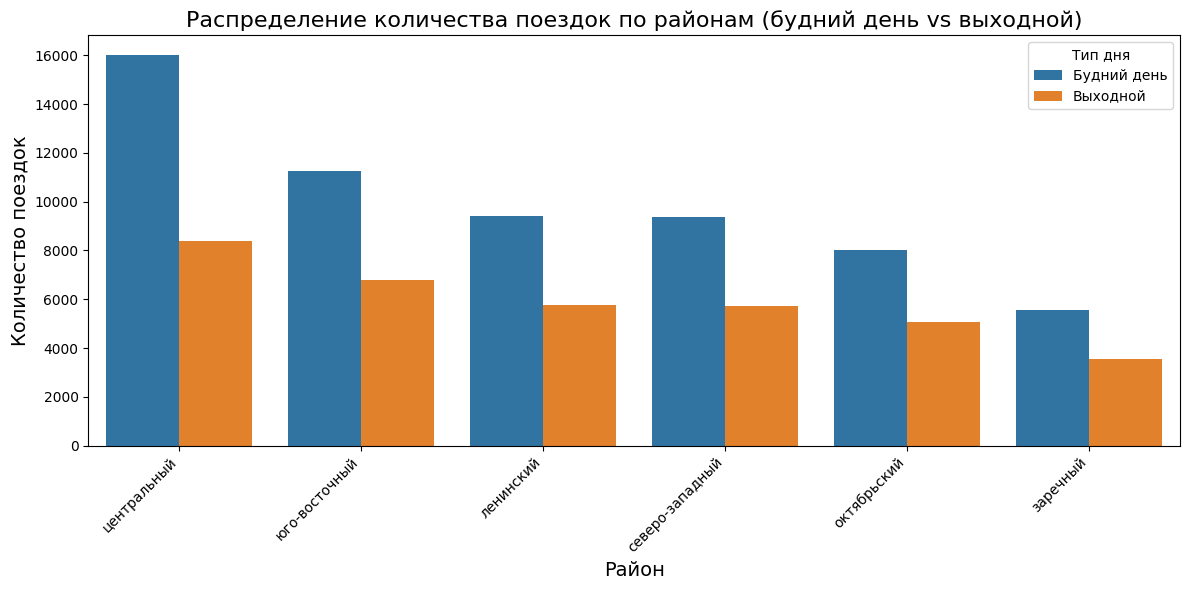

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

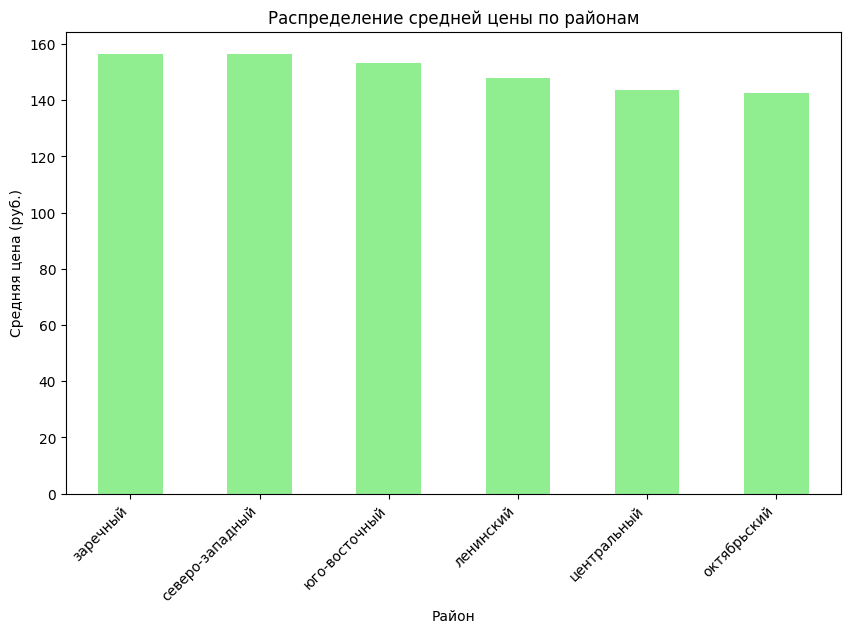

In [17]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

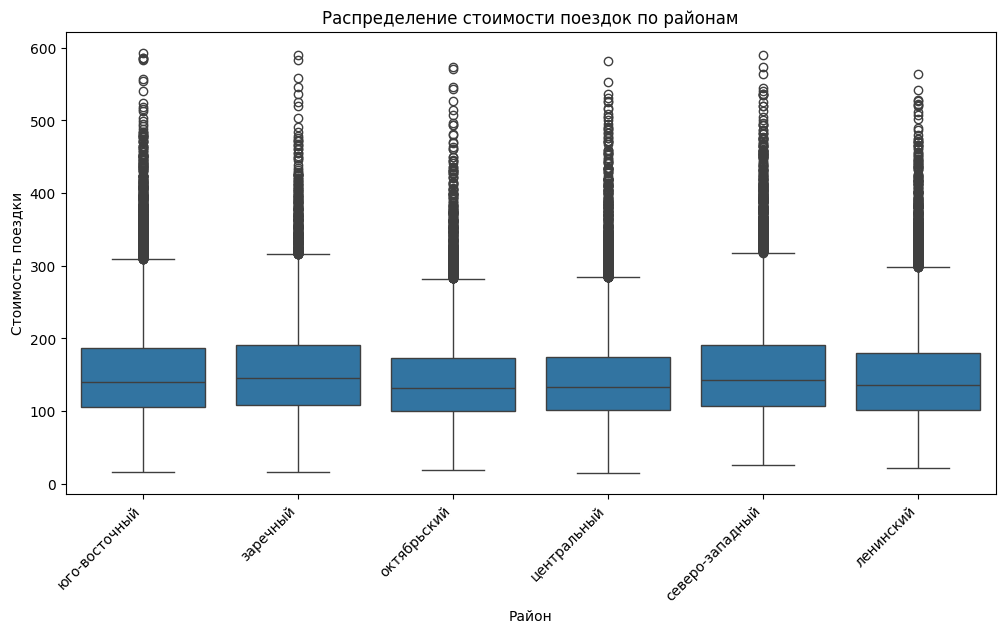

Start District
заречный           27.792169
северо-западный    27.683642
юго-восточный      27.183217
ленинский          26.145498
октябрьский        25.238809
центральный        25.200437
Name: Duration, dtype: float64


In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

In [19]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

149.17728010454653
593.3666666666667
137.41666666666669


C:\Temp\ipykernel_16988\615108698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")


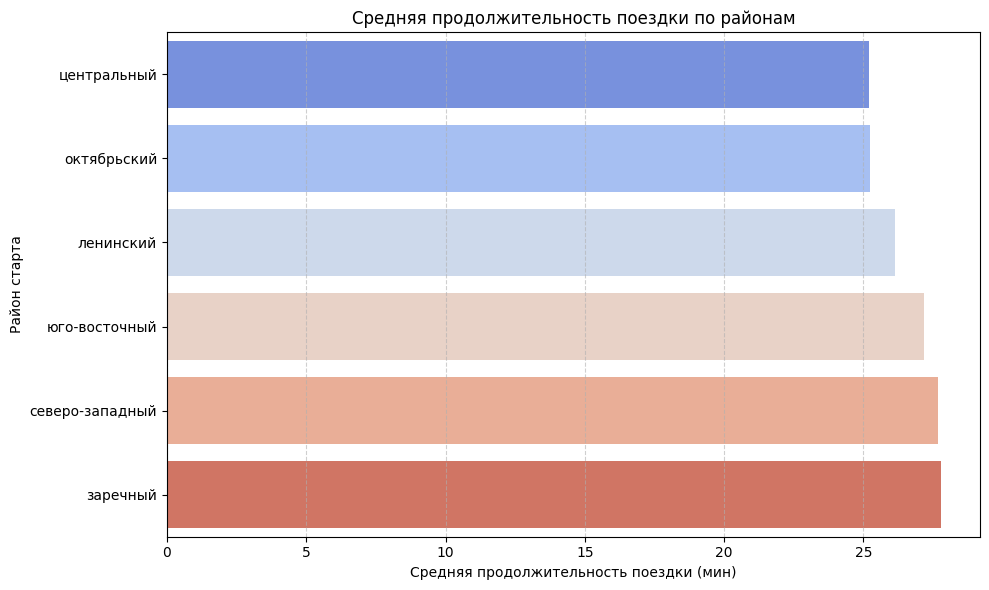

In [20]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

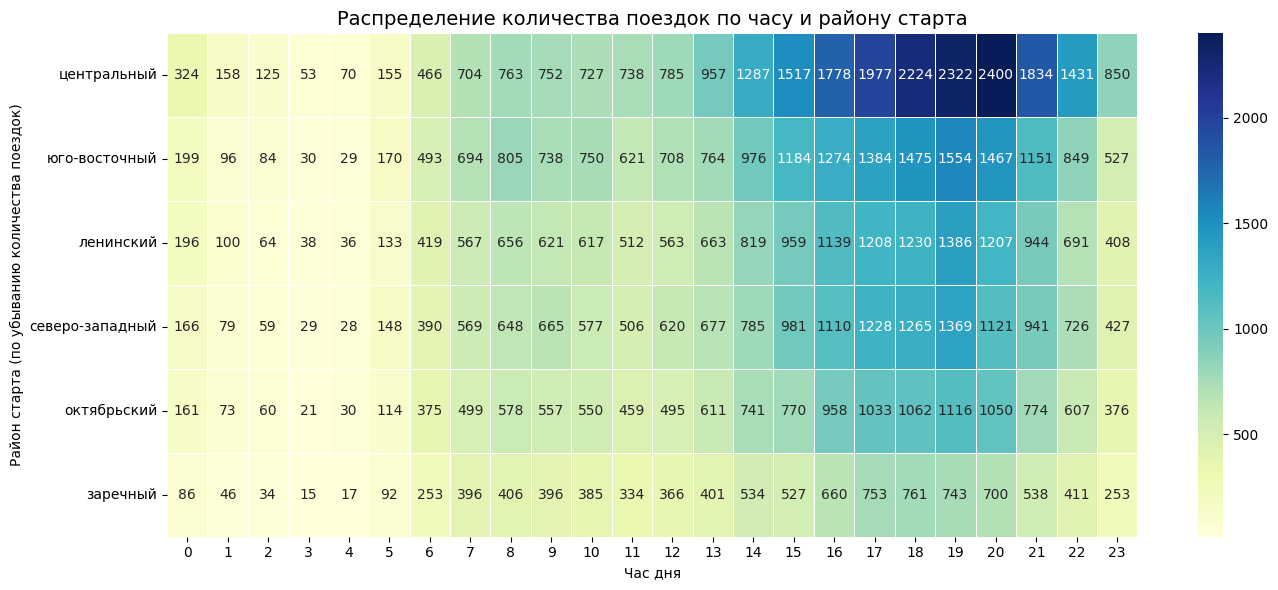

In [21]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

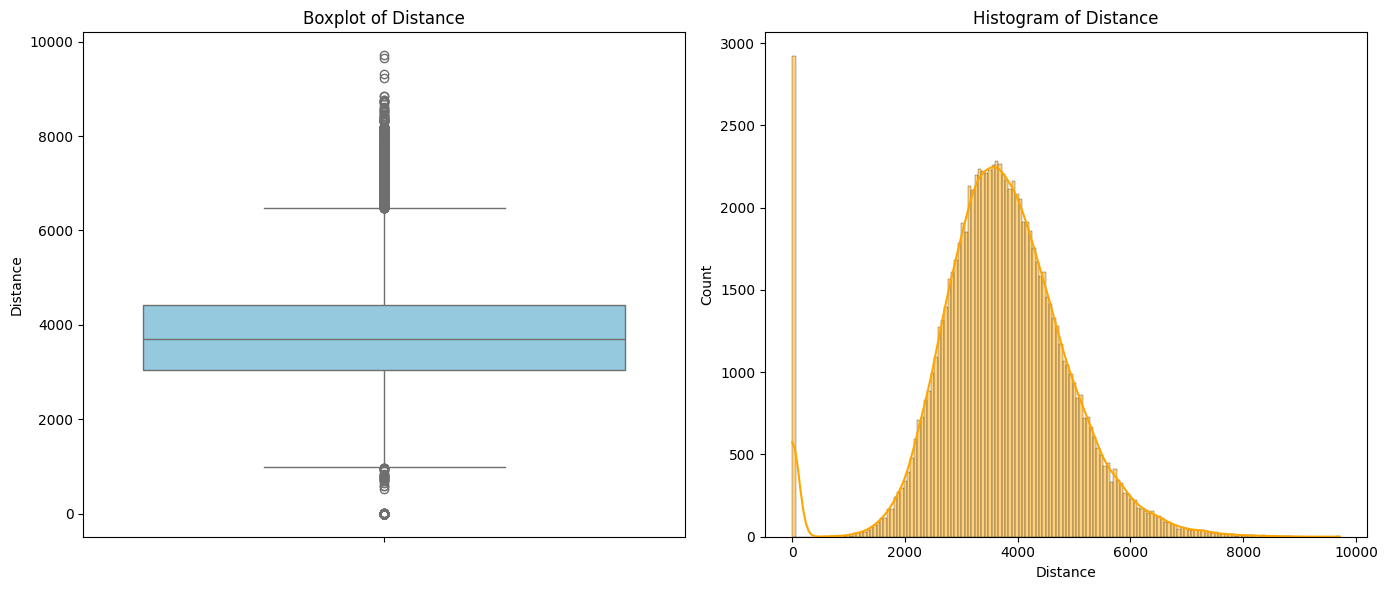

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
D:\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` varia

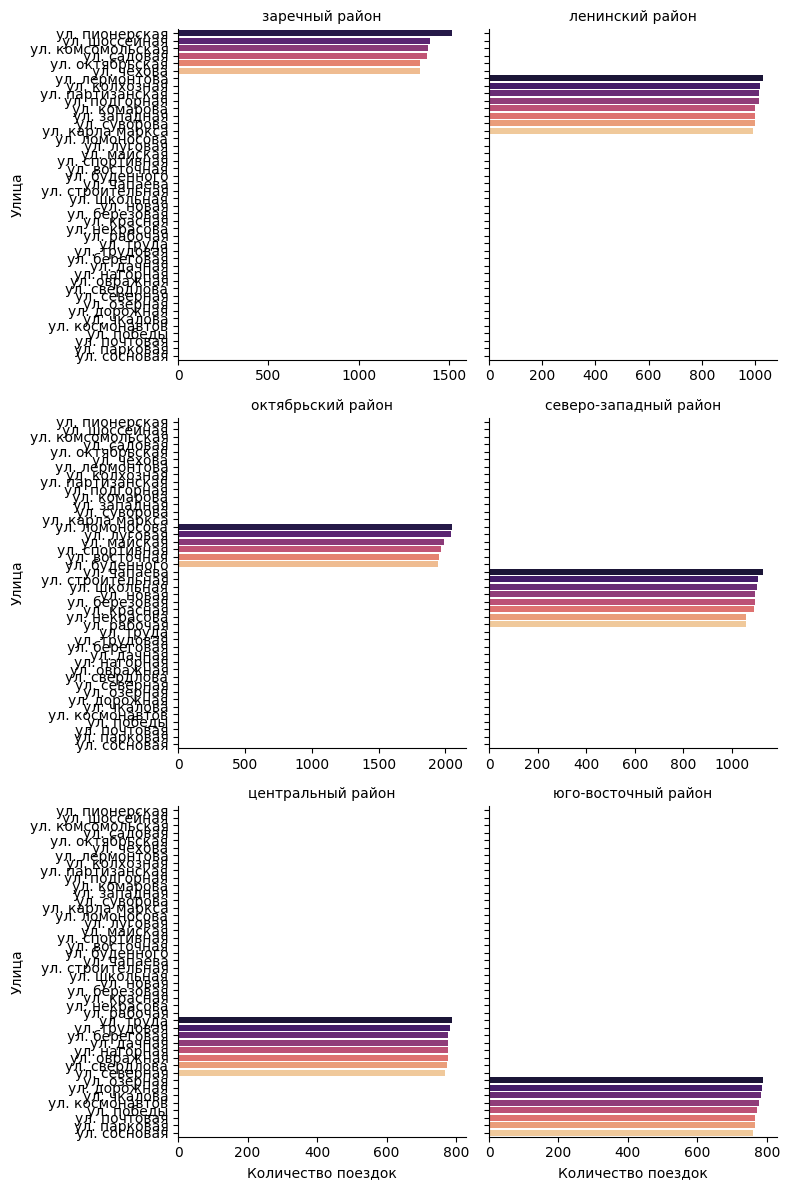

In [23]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import pearsonr, spearmanr, chi2_contingency

df1 = df.copy()

# Функция для вычисления корреляции между столбцами
def calc_correlation(col1, col2):
    if col1.dtype == 'object' and col2.dtype == 'object':
        contingency_table = pd.crosstab(col1, col2)
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
        return cramer_v
    elif col1.dtype != 'object' and col2.dtype != 'object':  # Числовые-Числовые
        corr, _ = pearsonr(col1, col2)
        return corr
    else:  # Числовые-Категориальные
        # Применяем тест хи-квадрат или ранговую корреляцию
        if col1.dtype != 'object':  # Числовой столбец в первом месте
            corr, _ = spearmanr(col1, col2)
        else:  # Числовой столбец во втором месте
            corr, _ = spearmanr(col2, col1)
        return corr

# Создаем пустую матрицу для хранения корреляций
columns = list(df1.columns)
columns.remove('Start Date')
columns.remove('End Date')
columns.remove('Id')
columns.remove('Duration')
correlation_matrix = pd.DataFrame(index=columns, columns=columns)

# Заполняем матрицу корреляции
for col1 in columns:
    for col2 in columns:
        correlation_matrix.loc[col1, col2] = calc_correlation(df1[col1], df1[col2])

# Преобразуем все значения в числовой формат для дальнейшего отображения
correlation_matrix = correlation_matrix.astype(float)

# Строим тепловую карту для отображения матрицы корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
plt.show()

D:\anaconda3\Lib\site-packages\pandas\core\reshape\reshape.py:143: RuntimeWarning: overflow encountered in scalar multiply
  num_cells = num_rows * num_columns


ValueError: negative dimensions are not allowed

In [ ]:
# Список международных праздников (в формате день.месяц)
holidays = [
    '01-01', # Новый год
    '23-02', # 23 февраля
    '08-03', # 8 марта
    '01-05', # 1 мая
    '09-05', # День Победы
    '12-06', # День России
    '04-11', # День народного единства
    '25-12'  # Рождество
]

# Функция для проверки, является ли дата праздником
def is_holiday(date):
    # Проверяем, не является ли дата NaT, перед использованием strftime
    if pd.isnull(date):
        return False
    return date.strftime('%d-%m') in holidays

# Применяем функцию ко всем датам в столбце 'Datetime' и создаем новый столбец 'Holiday'
df['Holiday'] = df['Start Date'].apply(is_holiday)

# Выведем несколько строк, чтобы убедиться, что новый столбец добавлен правильно
print(df.head())

# Теперь нам нужно подсчитать, сколько самокатов было взято в праздничные и обычные дни
# Предположим, что у нас есть столбец с количеством арендуемых самокатов, например 'Scooter Rentals'
# (если этого столбца нет в ваших данных, замените его на актуальный столбец)

# Для примера, если у нас есть столбец "Scooter Rentals" или его аналог, мы можем группировать по праздникам
# Например, будем использовать случайный столбец 'Temperature' для сравнения, если нет столбца аренды самокатов.

# Группировка по столбцу 'Holiday' и суммирование по любому числовому столбцу
df_grouped = df.groupby('Holiday')['Temperature'].count()  # Замените на столбец с количеством самокатов

# Построим график
plt.figure(figsize=(10, 6))
df_grouped.plot(kind='bar', color='lightcoral')
plt.title('Частота аренды самокатов в праздничные и обычные дни')
plt.xlabel('Праздничный день')
plt.ylabel('Частота аренды')
plt.xticks([0, 1], ['Обычные дни', 'Праздничные дни'], rotation=0)
plt.show()